NETFLIX DATASET LOADED SUCCESSFULLY

First 5 Rows
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021 

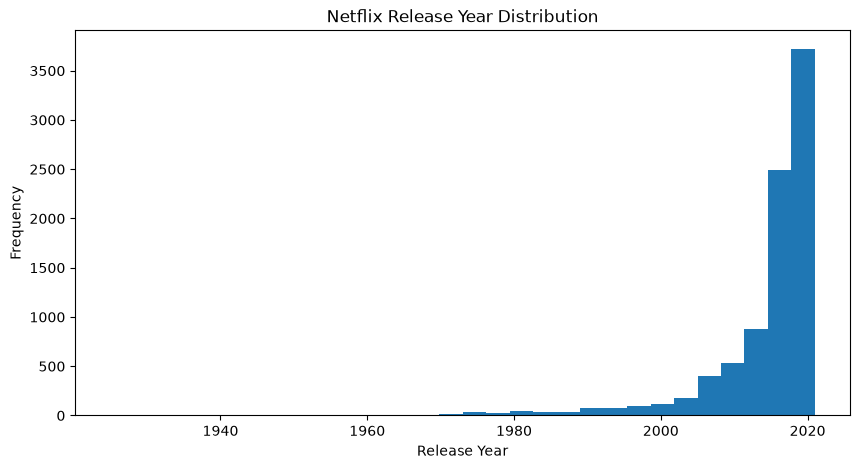

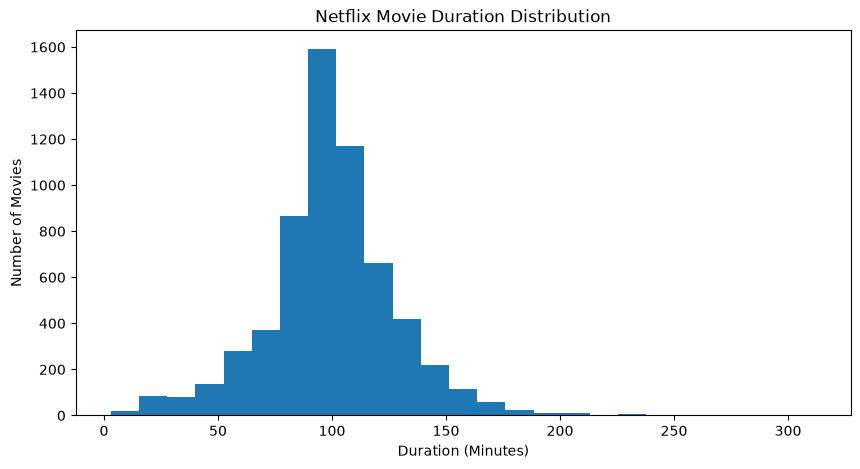

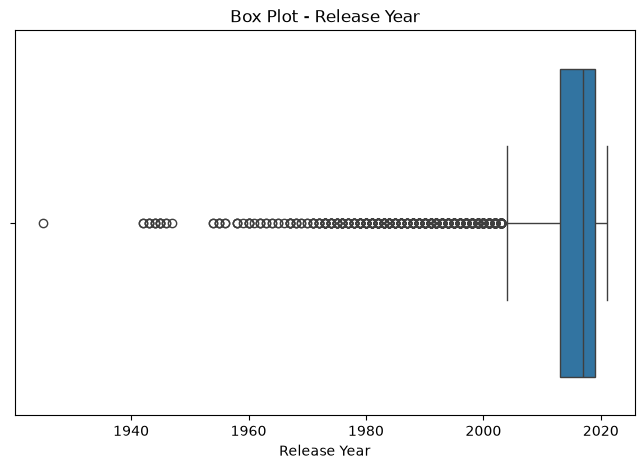

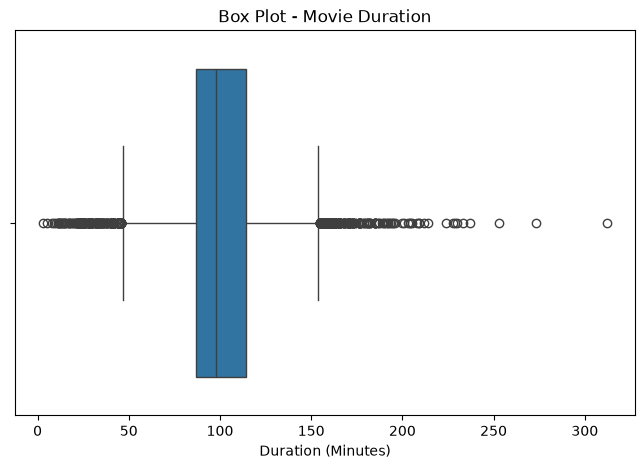

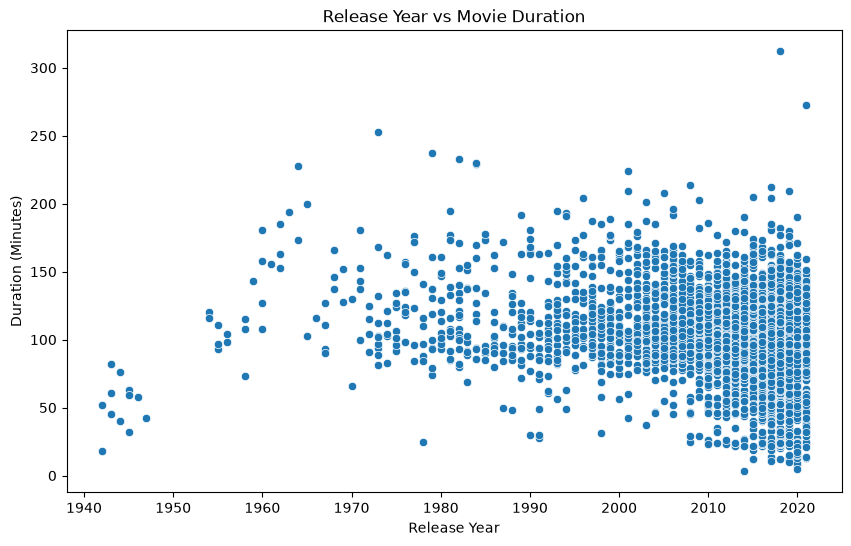

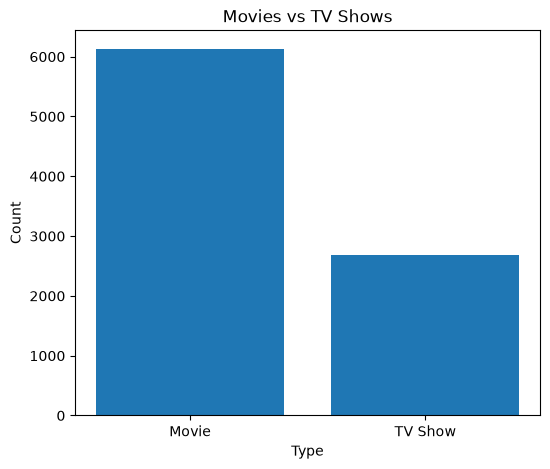

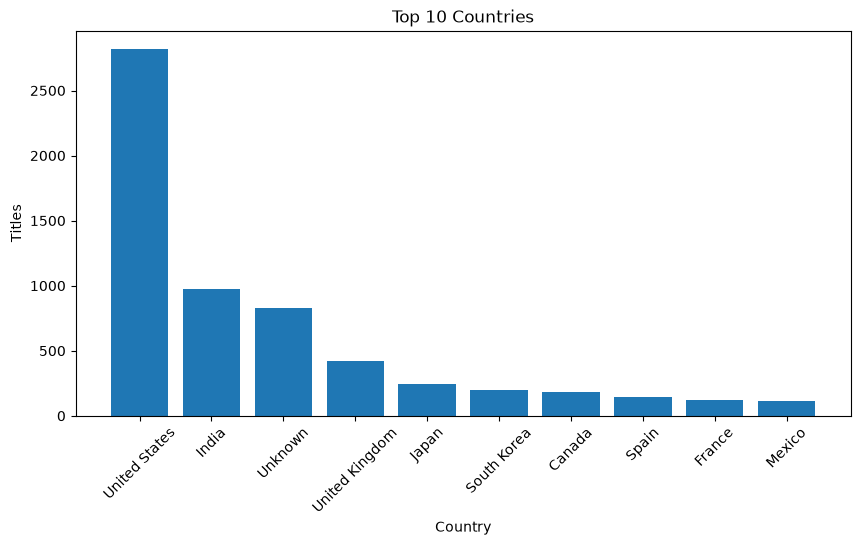

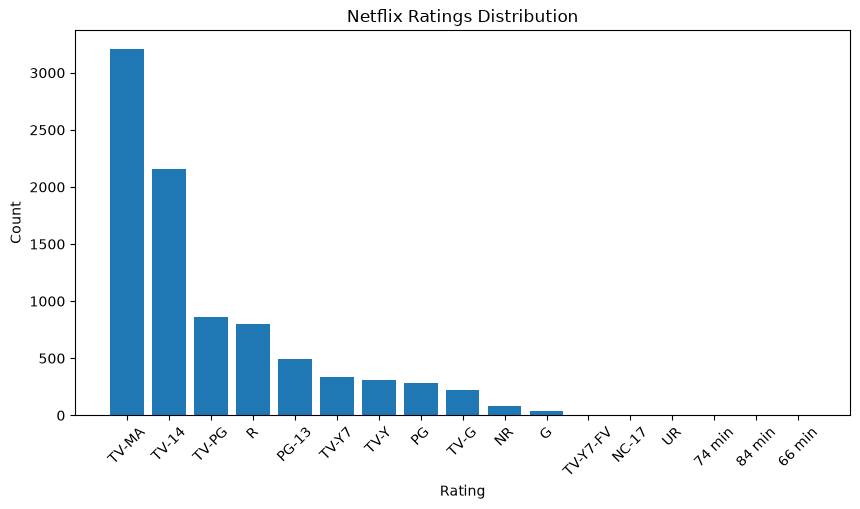

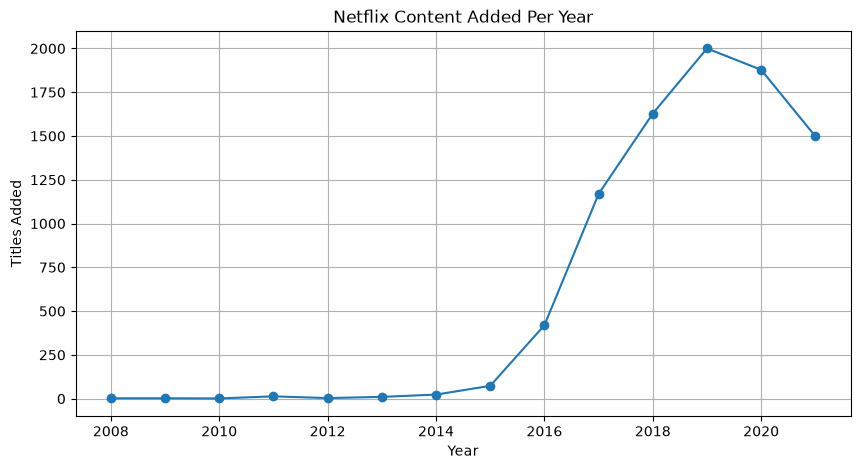

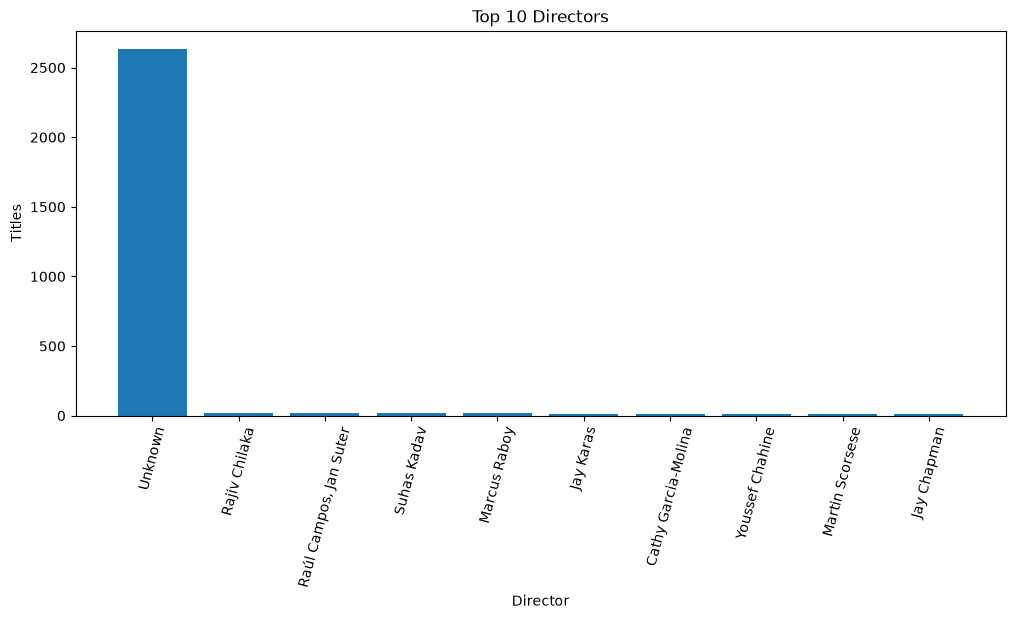

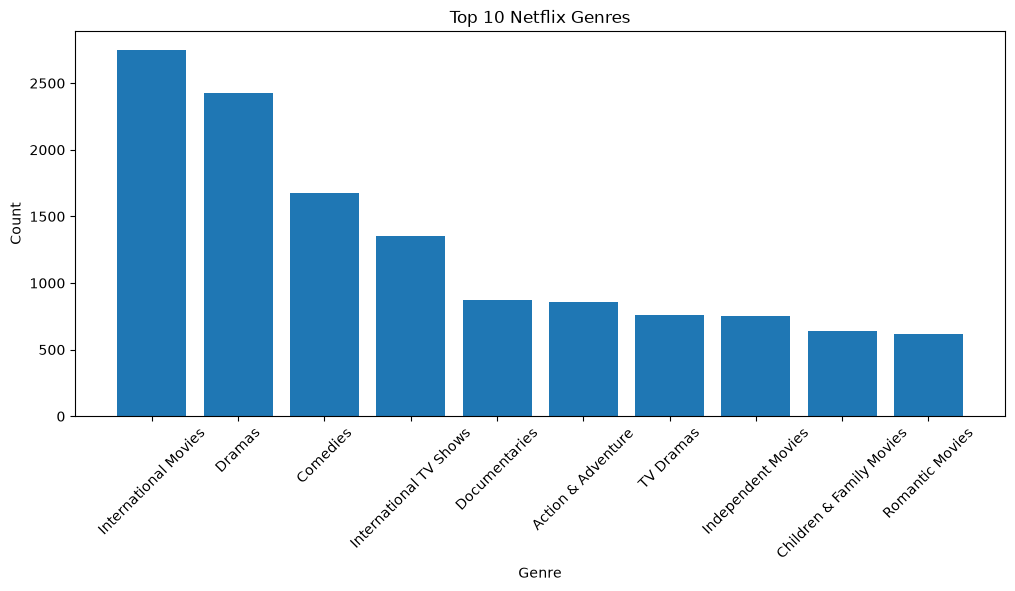



PART C - PROBABILITY BASICS

--- EVENT PROBABILITY ---
P(Movie) = 0.6961507891449983
P(TV Show) = 0.3038492108550017
P(Movie) + P(TV Show) = 1.0

--- CONDITIONAL PROBABILITY ---
P(Movie | TV-MA) = 0.6427904079725942
P(TV Show | TV-MA) = 0.3572095920274058

--- BAYES' THEOREM ---
P(Movie | TV-MA) using Bayes = 0.6427904079725942
P(Movie | TV-MA) directly = 0.6427904079725942


PART D - PROBABILITY DISTRIBUTIONS

--- NORMAL DISTRIBUTION ---
Mean Duration: 99.57718668407311
Standard Deviation: 28.290593447417397


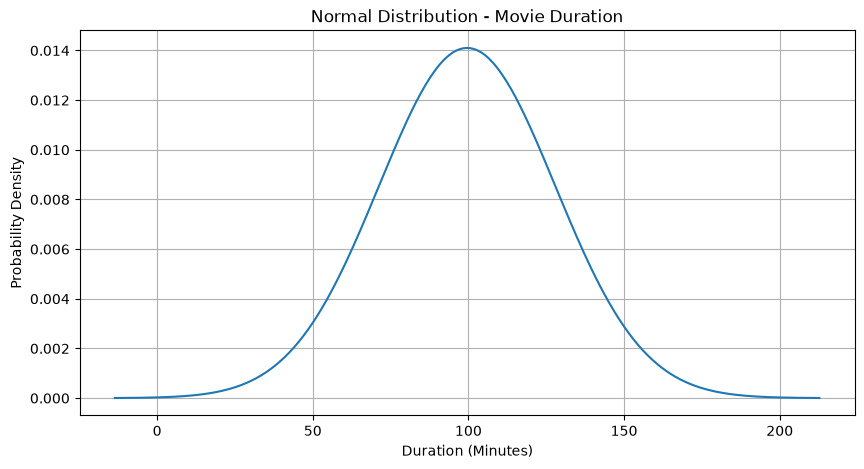


--- BINOMIAL DISTRIBUTION ---

Probability of exactly 5 Movies among 10 randomly selected titles:
0.10671063480522189


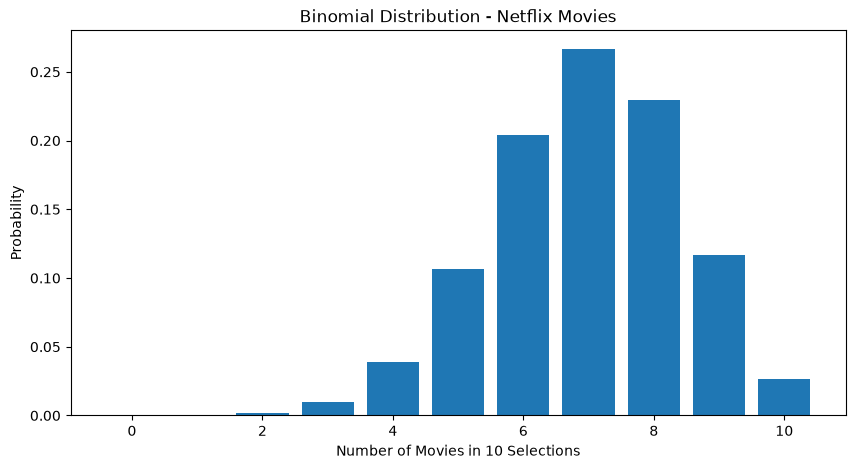


--- POISSON DISTRIBUTION ---
Average Titles Added Per Year: 622.7857142857143


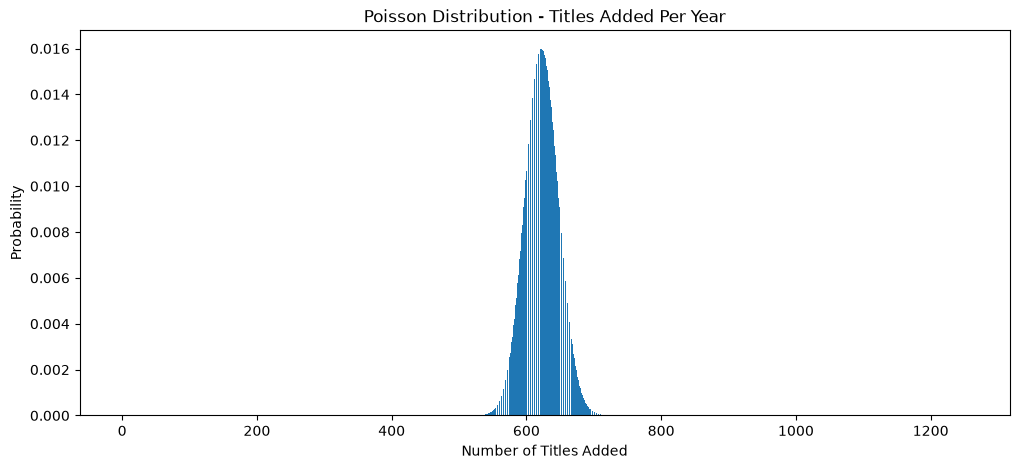



DISTRIBUTION SUMMARY

NORMAL DISTRIBUTION
-------------------
Used for continuous numerical data
that approximately follows a bell-shaped pattern.

Netflix example:
Movie duration can be analyzed for
approximately normal behavior.


BINOMIAL DISTRIBUTION
---------------------
Used when:
1. There are a fixed number of trials.
2. Each trial has two outcomes.
3. Probability of success is constant.

Netflix example:
Randomly selecting 10 titles and counting
how many are Movies.


POISSON DISTRIBUTION
--------------------
Used for counting events occurring
during a fixed interval.

Netflix example:
Number of Netflix titles added per year.


Cleaned Dataset Saved Successfully


FINAL DATASET INFORMATION
Final Shape: (8807, 13)

Remaining Missing Values
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      88
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added   

In [4]:
# ==========================================================
# NETFLIX DATA ANALYSIS
# PREPROCESSING + STATISTICS + VISUALIZATION
# PROBABILITY + DISTRIBUTIONS
#
# Python 3.14
# Pandas 3.x
# ==========================================================


# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy import stats


# ==========================================================
# 2. LOAD DATASET
# ==========================================================

file_name = "netflix_titles(1).csv"

if not os.path.exists(file_name):

    print("Dataset not found!")
    print("Current Folder:", os.getcwd())
    print("Files:", os.listdir())

    raise FileNotFoundError(file_name)


df = pd.read_csv(file_name)


print("=" * 70)
print("NETFLIX DATASET LOADED SUCCESSFULLY")
print("=" * 70)


# ==========================================================
# 3. BASIC DATASET INFORMATION
# ==========================================================

print("\nFirst 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nDataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nDataset Information")
df.info()


# ==========================================================
# 4. MISSING VALUES
# ==========================================================

print("\nMissing Values Before Cleaning")

print(df.isnull().sum())


# ==========================================================
# 5. DUPLICATES
# ==========================================================

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print(
    "Duplicate Rows After Cleaning:",
    df.duplicated().sum()
)


# ==========================================================
# 6. HANDLE MISSING VALUES
# ==========================================================

df["director"] = df["director"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Not Available")

df["country"] = df["country"].fillna("Unknown")


# Fill rating using mode

df["rating"] = df["rating"].fillna(
    df["rating"].mode().iloc[0]
)


# Forward fill date_added

df["date_added"] = df["date_added"].ffill()


# ==========================================================
# 7. DATE CONVERSION
# ==========================================================

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)


# ==========================================================
# 8. FINAL MISSING VALUE CHECK
# ==========================================================

print("\nMissing Values After Cleaning")

print(df.isnull().sum())


# ==========================================================
# 9. DATA TYPES
# ==========================================================

print("\nData Types")

print(df.dtypes)


# ==========================================================
# 10. CREATE YEAR ADDED
# ==========================================================

df["year_added"] = df["date_added"].dt.year


# ==========================================================
# 11. MOVIE DURATION CLEANING
# ==========================================================

movies = df[df["type"] == "Movie"].copy()


movies["duration"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False)
)


movies["duration"] = pd.to_numeric(
    movies["duration"],
    errors="coerce"
)


movie_duration = movies["duration"].dropna()


# ==========================================================
# ==========================================================
# PART A
# DESCRIPTIVE STATISTICS
# ==========================================================
# ==========================================================


print("\n")
print("=" * 70)
print("PART A - DESCRIPTIVE STATISTICS")
print("=" * 70)


# ==========================================================
# 12. RELEASE YEAR STATISTICS
# ==========================================================

release_year = df["release_year"].dropna()


print("\n--- RELEASE YEAR ---")


# Mean

mean_year = release_year.mean()

print("Mean:", mean_year)


# Median

median_year = release_year.median()

print("Median:", median_year)


# Mode

mode_year = release_year.mode()

print("Mode:", mode_year.tolist())


# Variance

variance_year = release_year.var()

print("Variance:", variance_year)


# Standard Deviation

std_year = release_year.std()

print("Standard Deviation:", std_year)


# Percentiles

p25_year = release_year.quantile(0.25)

p50_year = release_year.quantile(0.50)

p75_year = release_year.quantile(0.75)

print("25th Percentile:", p25_year)

print("50th Percentile:", p50_year)

print("75th Percentile:", p75_year)


# Complete summary

print("\nComplete Release Year Summary")

print(release_year.describe())


# ==========================================================
# 13. MOVIE DURATION STATISTICS
# ==========================================================

print("\n--- MOVIE DURATION ---")


# Mean

mean_duration = movie_duration.mean()

print(
    "Mean:",
    mean_duration,
    "minutes"
)


# Median

median_duration = movie_duration.median()

print(
    "Median:",
    median_duration,
    "minutes"
)


# Mode

mode_duration = movie_duration.mode()

print(
    "Mode:",
    mode_duration.tolist(),
    "minutes"
)


# Variance

variance_duration = movie_duration.var()

print(
    "Variance:",
    variance_duration
)


# Standard deviation

std_duration = movie_duration.std()

print(
    "Standard Deviation:",
    std_duration,
    "minutes"
)


# Percentiles

p25_duration = movie_duration.quantile(0.25)

p50_duration = movie_duration.quantile(0.50)

p75_duration = movie_duration.quantile(0.75)


print(
    "25th Percentile:",
    p25_duration,
    "minutes"
)

print(
    "50th Percentile:",
    p50_duration,
    "minutes"
)

print(
    "75th Percentile:",
    p75_duration,
    "minutes"
)


print("\nComplete Movie Duration Summary")

print(movie_duration.describe())


# ==========================================================
# ==========================================================
# PART B
# DATA VISUALIZATION
# ==========================================================
# ==========================================================


print("\n")
print("=" * 70)
print("PART B - DATA VISUALIZATION")
print("=" * 70)


# ==========================================================
# 14. HISTOGRAM
# RELEASE YEAR
# ==========================================================

plt.figure(figsize=(10, 5))

plt.hist(
    release_year,
    bins=30
)

plt.title("Netflix Release Year Distribution")

plt.xlabel("Release Year")

plt.ylabel("Frequency")

plt.show()


# ==========================================================
# 15. HISTOGRAM
# MOVIE DURATION
# ==========================================================

plt.figure(figsize=(10, 5))

plt.hist(
    movie_duration,
    bins=25
)

plt.title("Netflix Movie Duration Distribution")

plt.xlabel("Duration (Minutes)")

plt.ylabel("Number of Movies")

plt.show()


# ==========================================================
# 16. BOX PLOT
# RELEASE YEAR
# ==========================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=release_year
)

plt.title("Box Plot - Release Year")

plt.xlabel("Release Year")

plt.show()


# ==========================================================
# 17. BOX PLOT
# MOVIE DURATION
# ==========================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=movie_duration
)

plt.title("Box Plot - Movie Duration")

plt.xlabel("Duration (Minutes)")

plt.show()


# ==========================================================
# 18. SCATTER PLOT
# RELEASE YEAR vs MOVIE DURATION
# ==========================================================

# Create a separate dataframe containing
# release year and duration

movie_analysis = movies[
    ["release_year", "duration"]
].dropna()


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movie_analysis,
    x="release_year",
    y="duration"
)

plt.title(
    "Release Year vs Movie Duration"
)

plt.xlabel("Release Year")

plt.ylabel("Duration (Minutes)")

plt.show()


# ==========================================================
# 19. MOVIES VS TV SHOWS
# ==========================================================

type_count = df["type"].value_counts()


plt.figure(figsize=(6, 5))

plt.bar(
    type_count.index,
    type_count.values
)

plt.title("Movies vs TV Shows")

plt.xlabel("Type")

plt.ylabel("Count")

plt.show()


# ==========================================================
# 20. TOP 10 COUNTRIES
# ==========================================================

country = df["country"].value_counts().head(10)


plt.figure(figsize=(10, 5))

plt.bar(
    country.index,
    country.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries")

plt.xlabel("Country")

plt.ylabel("Titles")

plt.show()


# ==========================================================
# 21. RATINGS DISTRIBUTION
# ==========================================================

rating = df["rating"].value_counts()


plt.figure(figsize=(10, 5))

plt.bar(
    rating.index,
    rating.values
)

plt.xticks(rotation=45)

plt.title("Netflix Ratings Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()


# ==========================================================
# 22. CONTENT ADDED PER YEAR
# ==========================================================

year = (
    df["year_added"]
    .value_counts()
    .sort_index()
)


plt.figure(figsize=(10, 5))

plt.plot(
    year.index,
    year.values,
    marker="o"
)

plt.title(
    "Netflix Content Added Per Year"
)

plt.xlabel("Year")

plt.ylabel("Titles Added")

plt.grid(True)

plt.show()


# ==========================================================
# 23. TOP 10 DIRECTORS
# ==========================================================

director = (
    df["director"]
    .value_counts()
    .head(10)
)


plt.figure(figsize=(12, 5))

plt.bar(
    director.index,
    director.values
)

plt.xticks(rotation=75)

plt.title("Top 10 Directors")

plt.xlabel("Director")

plt.ylabel("Titles")

plt.show()


# ==========================================================
# 24. TOP 10 GENRES
# ==========================================================

genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)


top_genres = (
    genres
    .value_counts()
    .head(10)
)


plt.figure(figsize=(12, 5))

plt.bar(
    top_genres.index,
    top_genres.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Netflix Genres")

plt.xlabel("Genre")

plt.ylabel("Count")

plt.show()


# ==========================================================
# ==========================================================
# PART C
# PROBABILITY BASICS
# ==========================================================
# ==========================================================


print("\n")
print("=" * 70)
print("PART C - PROBABILITY BASICS")
print("=" * 70)


# ==========================================================
# 25. EVENTS
# ==========================================================

print("\n--- EVENT PROBABILITY ---")


# Event A:
# Randomly selected Netflix title is a Movie

total_titles = len(df)

movie_count = (
    df["type"] == "Movie"
).sum()


P_movie = movie_count / total_titles


print(
    "P(Movie) =",
    P_movie
)


# Event B:
# Randomly selected Netflix title is a TV Show

tv_count = (
    df["type"] == "TV Show"
).sum()


P_tv = tv_count / total_titles


print(
    "P(TV Show) =",
    P_tv
)


# Check that probabilities add to approximately 1

print(
    "P(Movie) + P(TV Show) =",
    P_movie + P_tv
)


# ==========================================================
# 26. CONDITIONAL PROBABILITY
# ==========================================================

print("\n--- CONDITIONAL PROBABILITY ---")


# Question:
#
# What is the probability that a Netflix title is a Movie
# given that its rating is TV-MA?


tv_ma_titles = df[
    df["rating"] == "TV-MA"
]


P_movie_given_tvma = (
    (tv_ma_titles["type"] == "Movie").sum()
    /
    len(tv_ma_titles)
)


print(
    "P(Movie | TV-MA) =",
    P_movie_given_tvma
)


# Another example:
#
# Probability of TV Show given TV-MA

P_tv_given_tvma = (
    (tv_ma_titles["type"] == "TV Show").sum()
    /
    len(tv_ma_titles)
)


print(
    "P(TV Show | TV-MA) =",
    P_tv_given_tvma
)


# ==========================================================
# 27. BAYES' THEOREM
# ==========================================================

print("\n--- BAYES' THEOREM ---")


# Events:
#
# A = Movie
# B = TV-MA rating
#
# We want:
#
# P(Movie | TV-MA)


P_movie = (
    (df["type"] == "Movie").sum()
    /
    len(df)
)


P_tvma = (
    (df["rating"] == "TV-MA").sum()
    /
    len(df)
)


P_tvma_given_movie = (
    (
        (df["type"] == "Movie")
        &
        (df["rating"] == "TV-MA")
    ).sum()
    /
    (df["type"] == "Movie").sum()
)


bayes_result = (
    P_tvma_given_movie
    * P_movie
    / P_tvma
)


print(
    "P(Movie | TV-MA) using Bayes =",
    bayes_result
)


print(
    "P(Movie | TV-MA) directly =",
    P_movie_given_tvma
)


# ==========================================================
# ==========================================================
# PART D
# PROBABILITY DISTRIBUTIONS
# ==========================================================
# ==========================================================


print("\n")
print("=" * 70)
print("PART D - PROBABILITY DISTRIBUTIONS")
print("=" * 70)


# ==========================================================
# 28. NORMAL DISTRIBUTION
# ==========================================================

print("\n--- NORMAL DISTRIBUTION ---")


# We use movie duration as a numerical example.
#
# Calculate mean and standard deviation

mu = movie_duration.mean()

sigma = movie_duration.std()


print("Mean Duration:", mu)

print("Standard Deviation:", sigma)


# Create values around the mean

x = np.linspace(
    mu - 4 * sigma,
    mu + 4 * sigma,
    300
)


# Normal probability density

normal_pdf = stats.norm.pdf(
    x,
    mu,
    sigma
)


plt.figure(figsize=(10, 5))

plt.plot(
    x,
    normal_pdf
)

plt.title(
    "Normal Distribution - Movie Duration"
)

plt.xlabel("Duration (Minutes)")

plt.ylabel("Probability Density")

plt.grid(True)

plt.show()


# ==========================================================
# 29. BINOMIAL DISTRIBUTION
# ==========================================================

print("\n--- BINOMIAL DISTRIBUTION ---")


# Example:
#
# Suppose we randomly select 10 Netflix titles.
#
# Success = selected title is a Movie
#
# Probability of success = P(Movie)
#
# We calculate probability of getting exactly k Movies.


n = 10

p = P_movie


k = np.arange(
    0,
    n + 1
)


binomial_probability = stats.binom.pmf(
    k,
    n,
    p
)


print(
    "\nProbability of exactly 5 Movies "
    "among 10 randomly selected titles:"
)


print(
    stats.binom.pmf(
        5,
        n,
        p
    )
)


plt.figure(figsize=(10, 5))

plt.bar(
    k,
    binomial_probability
)

plt.title(
    "Binomial Distribution - Netflix Movies"
)

plt.xlabel(
    "Number of Movies in 10 Selections"
)

plt.ylabel(
    "Probability"
)

plt.show()


# ==========================================================
# 30. POISSON DISTRIBUTION
# ==========================================================

print("\n--- POISSON DISTRIBUTION ---")


# Poisson is useful for counting events
# occurring during a fixed interval.
#
# Example:
#
# Number of Netflix titles added per year.
#
# Calculate average number of titles added per year.


titles_per_year = (
    df["year_added"]
    .value_counts()
)


lambda_value = (
    titles_per_year.mean()
)


print(
    "Average Titles Added Per Year:",
    lambda_value
)


# Create possible event counts

k_poisson = np.arange(
    0,
    int(lambda_value * 2) + 10
)


poisson_probability = stats.poisson.pmf(
    k_poisson,
    lambda_value
)


plt.figure(figsize=(12, 5))

plt.bar(
    k_poisson,
    poisson_probability
)

plt.title(
    "Poisson Distribution - Titles Added Per Year"
)

plt.xlabel(
    "Number of Titles Added"
)

plt.ylabel(
    "Probability"
)

plt.show()


# ==========================================================
# 31. DISTRIBUTION SUMMARY
# ==========================================================

print("\n")
print("=" * 70)
print("DISTRIBUTION SUMMARY")
print("=" * 70)


print("""
NORMAL DISTRIBUTION
-------------------
Used for continuous numerical data
that approximately follows a bell-shaped pattern.

Netflix example:
Movie duration can be analyzed for
approximately normal behavior.


BINOMIAL DISTRIBUTION
---------------------
Used when:
1. There are a fixed number of trials.
2. Each trial has two outcomes.
3. Probability of success is constant.

Netflix example:
Randomly selecting 10 titles and counting
how many are Movies.


POISSON DISTRIBUTION
--------------------
Used for counting events occurring
during a fixed interval.

Netflix example:
Number of Netflix titles added per year.
""")


# ==========================================================
# 32. SAVE CLEANED DATASET
# ==========================================================

df.to_csv(
    "netflix_cleaned.csv",
    index=False
)


print("\nCleaned Dataset Saved Successfully")


# ==========================================================
# 33. FINAL INFORMATION
# ==========================================================

print("\n")
print("=" * 70)
print("FINAL DATASET INFORMATION")
print("=" * 70)


print("Final Shape:", df.shape)


print("\nRemaining Missing Values")

print(df.isnull().sum())


print("\nFirst 10 Rows")

print(df.head(10))


print("\n")
print("=" * 70)
print("ALL NETFLIX ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 70)